In [1]:
!pip install econml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 68.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 50.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.9/151.9 kB 10.9 MB/s eta 0:00:00
  Attempting uninstall: shap
    Found existing installation: shap 0.52.0
    Uninstalling shap-0.52.0:
      Successfully uninstalled shap-0.52.0


In [2]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.4 MB/s eta 0:00:00


In [29]:
import joblib
import shap
import pandas as pd

df = pd.read_csv("/content/simulated_uplift_data.csv")


model = joblib.load("models/xlearner.pkl")

In [30]:
target_col = "Outcome"
treatment_col = "Treatment"

meta_cols = [
    "Y0",
    "Y1"
]

feature_cols = [
    c for c in df.columns
    if c not in [target_col, treatment_col] + meta_cols
]

X = df[feature_cols]

X_encoded = pd.get_dummies(
    X,
    drop_first=True
)

feature_columns = joblib.load(
    "models/feature_columns.pkl"
)

X_encoded = X_encoded.reindex(
    columns=feature_columns,
    fill_value=0
)

X_encoded = X_encoded.astype(float)

In [31]:
print(X_encoded.dtypes.unique())

[dtype('float64')]


In [32]:
print(type(feature_columns))
print(type(feature_columns[0]))
print(feature_columns[0])
print(len(feature_columns))

<class 'list'>
<class 'str'>
SeniorCitizen
7083


In [33]:
X_sample = X_encoded.sample(
    200,
    random_state=42
)

In [34]:
explainer = shap.Explainer(
    model.effect,
    X_sample
)

In [35]:
shap_values = explainer(
    X_sample
)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
PermutationExplainer explainer:   1%|          | 2/200 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6

/tmp/ipykernel_2232/1101180912.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


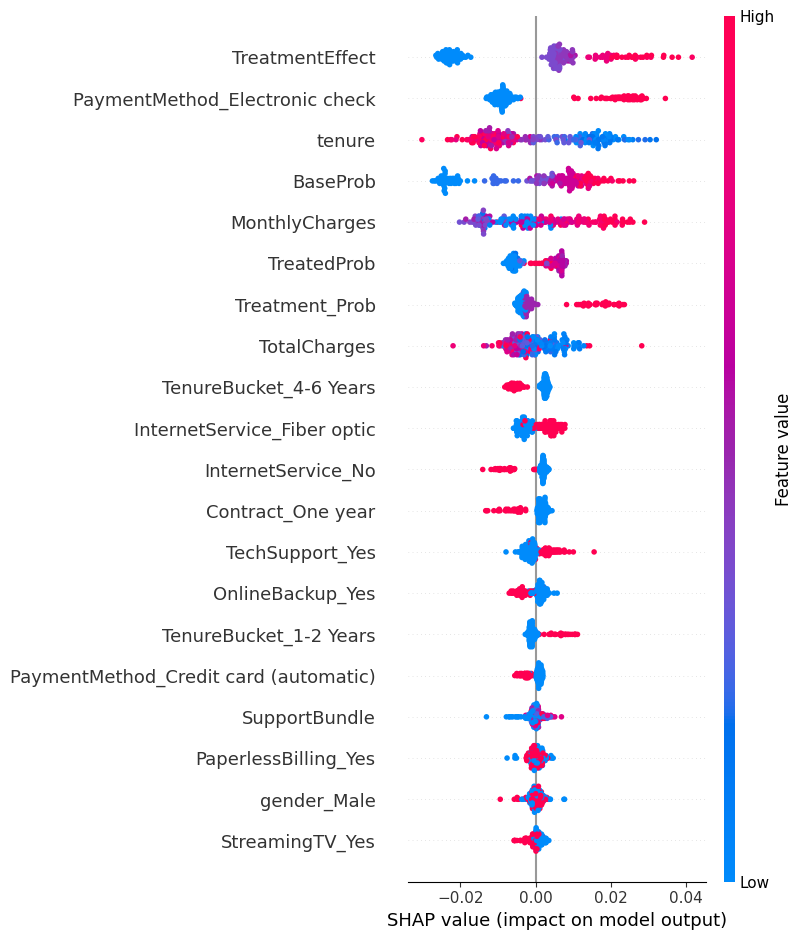

In [36]:
shap.summary_plot(
    shap_values,
    X_sample
)

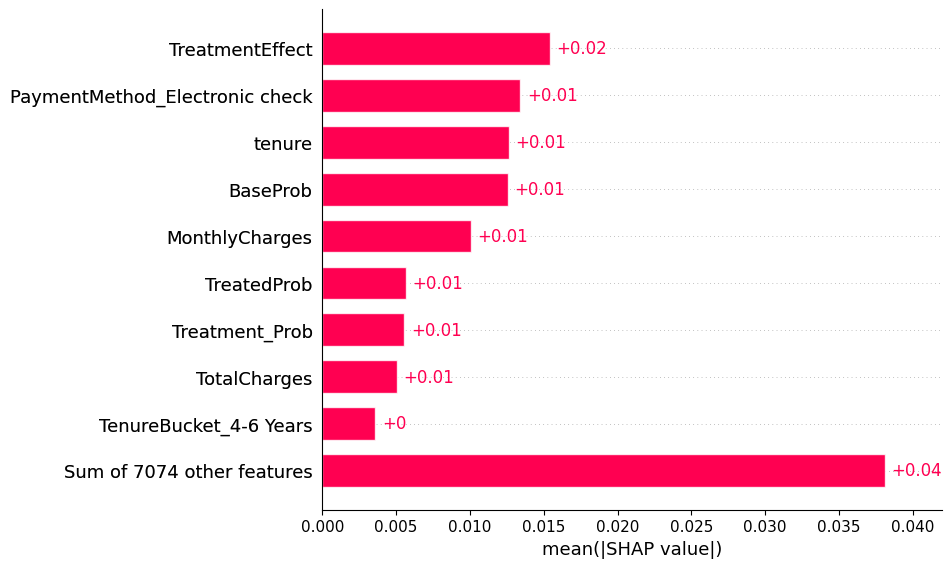

In [37]:
shap.plots.bar(
    shap_values
)